# 🏥 Healthcare Data Analysis —
**Dataset:** 55,500 inpatient records &nbsp;|&nbsp; **Tools:** Python · Pandas · SciPy · Scikit-learn · MySQL

**Pipeline:** Data Cleaning → Feature Engineering → EDA (7 dimensions) → Outlier Detection → Statistical Testing → Regression

---

In [1]:
# ── Download dataset from Kaggle ─────────────
import os

DATA_FILE = 'healthcare_dataset.csv'

if os.path.exists(DATA_FILE):
    print(f'✓ Dataset already present ({os.path.getsize(DATA_FILE)/1e6:.1f} MB) — skipping download.')
else:
    import opendatasets as od
    # Prompts once for Kaggle username + API key
    od.download('https://www.kaggle.com/datasets/prasad22/healthcare-dataset')
    # opendatasets saves to a subfolder — move CSV to current dir
    import shutil, glob
    matches = glob.glob('**/healthcare_dataset.csv', recursive=True)
    if matches:
        shutil.copy(matches[0], DATA_FILE)
        print(f'✓ Downloaded and ready: {DATA_FILE}')
    else:
        raise FileNotFoundError(
            'Download completed but CSV not found.\n'
            'Check the downloaded folder and copy healthcare_dataset.csv here manually.'
        )

✓ Dataset already present (8.4 MB) — skipping download.


## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

COLORS6 = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6','#06B6D4']
COLORS3 = ['#2563EB','#F59E0B','#10B981']

df = pd.read_csv(DATA_FILE)
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date']    = pd.to_datetime(df['Discharge Date'])

print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape  : (55500, 15)
Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal


## 2. Data Quality Check

In [3]:
print('=== Missing Values ===')
print(df.isnull().sum())

print(f'\nDuplicate rows: {df.duplicated().sum()}')

neg_billing = (df['Billing Amount'] < 0).sum()
print(f'\nNegative billing records : {neg_billing} ({neg_billing/len(df)*100:.2f}% of dataset)')
print('→ Flagged and excluded from all billing aggregations.')

df_clean = df[df['Billing Amount'] > 0].copy()
print(f'\nRecords for analysis     : {len(df_clean):,} (after excluding {neg_billing} negative billing rows)')

=== Missing Values ===
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Duplicate rows: 534

Negative billing records : 108 (0.19% of dataset)
→ Flagged and excluded from all billing aggregations.

Records for analysis     : 55,392 (after excluding 108 negative billing rows)


## 3. Feature Engineering

In [4]:
# LOS — primary length-of-stay metric
df['LOS'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df_clean['LOS'] = (df_clean['Discharge Date'] - df_clean['Date of Admission']).dt.days

# Age Group bins
bins   = [12, 29, 44, 59, 74, 89]
labels = ['13-29', '30-44', '45-59', '60-74', '75-89']
df['Age Group']       = pd.cut(df['Age'],       bins=bins, labels=labels)
df_clean['Age Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)

# Season from admission month
df['Admission Month'] = df['Date of Admission'].dt.month
df['Admission Year']  = df['Date of Admission'].dt.year
df['Season'] = df['Admission Month'].apply(
    lambda m: 'Winter' if m in [12,1,2]
         else 'Spring' if m in [3,4,5]
         else 'Summer' if m in [6,7,8]
         else 'Fall'
)
df_clean['Season']           = df['Season']
df_clean['Admission Month']  = df['Admission Month']
df_clean['Admission Year']   = df['Admission Year']

# Billing Tier (quartile-based)
df_clean['Billing Tier'] = pd.qcut(
    df_clean['Billing Amount'], q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

print('Feature engineering complete.')
print(f'  LOS range    : {df["LOS"].min()}–{df["LOS"].max()} days')
print(f'  Age groups   : {labels}')
print(f'  Seasons      : {df["Season"].value_counts().to_dict()}')
print(f'  Billing tiers: Low / Medium / High / Very High (quartile split)')

Feature engineering complete.
  LOS range    : 1–30 days
  Age groups   : ['13-29', '30-44', '45-59', '60-74', '75-89']
  Seasons      : {'Summer': 14343, 'Spring': 13789, 'Fall': 13772, 'Winter': 13596}
  Billing tiers: Low / Medium / High / Very High (quartile split)


## 4. Summary Statistics & KPIs

In [5]:
print('─── Core KPIs ──────────────────────────────────────────')
print(f'Total patients       : {len(df):,}')
print(f'Total billing (valid): ${df_clean["Billing Amount"].sum()/1e9:.2f}B')
print(f'Avg billing          : ${df_clean["Billing Amount"].mean():,.0f}')
print(f'Median billing       : ${df_clean["Billing Amount"].median():,.0f}')
print(f'Billing range        : ${df_clean["Billing Amount"].min():,.0f} – ${df_clean["Billing Amount"].max():,.0f}')
print(f'Avg LOS              : {df["LOS"].mean():.1f} days  (median: {int(df["LOS"].median())} days)')
print(f'Avg age              : {df["Age"].mean():.1f} years  (range: {df["Age"].min()}–{df["Age"].max()})')
print()
print('─── Gender ─────────────────────────────────────────────')
print(df['Gender'].value_counts())
print()
print('─── Conditions ─────────────────────────────────────────')
print(df['Medical Condition'].value_counts())
print()
print('─── Admission Types ────────────────────────────────────')
print(df['Admission Type'].value_counts())
print()
print('─── Test Results ───────────────────────────────────────')
print(df['Test Results'].value_counts())
ab_rate = (df['Test Results']=='Abnormal').mean()*100
print(f'\nOverall abnormal rate: {ab_rate:.1f}% ({(df["Test Results"]=="Abnormal").sum():,} patients)')

─── Core KPIs ──────────────────────────────────────────
Total patients       : 55,500
Total billing (valid): $1.42B
Avg billing          : $25,590
Median billing       : $25,574
Billing range        : $9 – $52,764
Avg LOS              : 15.5 days  (median: 15 days)
Avg age              : 51.5 years  (range: 13–89)

─── Gender ─────────────────────────────────────────────
Gender
Male      27774
Female    27726
Name: count, dtype: int64

─── Conditions ─────────────────────────────────────────
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

─── Admission Types ────────────────────────────────────
Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

─── Test Results ───────────────────────────────────────
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

Overall abno

## 5. Exploratory Data Analysis

### 5.1 Patient Demographics

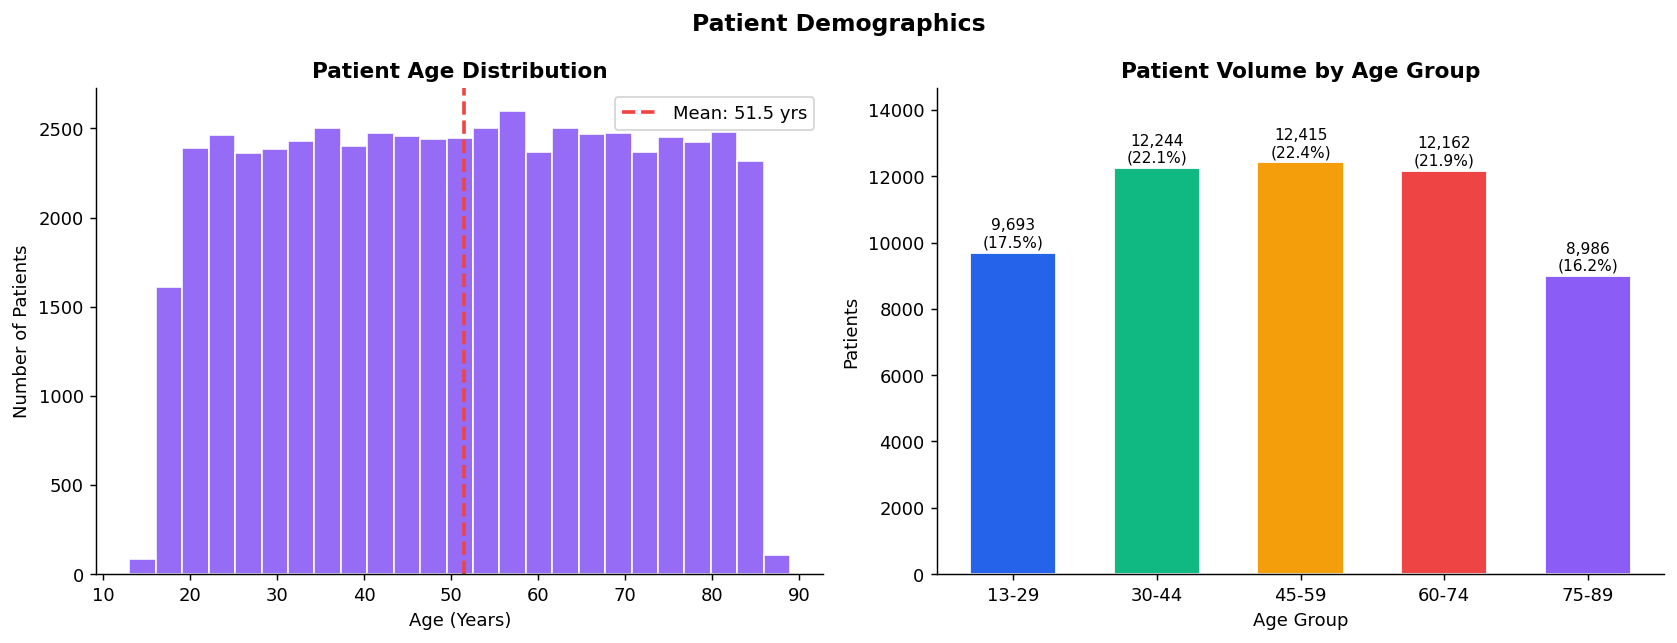

Mean age: 51.5 years
Largest cohort: 45-59 (22.4% of admissions)
Gender split: {'Male': np.float64(50.0), 'Female': np.float64(50.0)}


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age distribution
axes[0].hist(df['Age'], bins=25, color='#8B5CF6', edgecolor='white', alpha=0.9)
axes[0].axvline(df['Age'].mean(), color='#EF4444', lw=2, ls='--',
                label=f'Mean: {df["Age"].mean():.1f} yrs')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('Patient Age Distribution', fontweight='bold')
axes[0].legend()

# Age group bar
ag = df['Age Group'].value_counts().sort_index()
bars = axes[1].bar(ag.index, ag.values, color=COLORS6[:5], edgecolor='white', width=0.6)
for bar, val in zip(bars, ag.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+80,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=8.5)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Patients')
axes[1].set_title('Patient Volume by Age Group', fontweight='bold')
axes[1].set_ylim(0, ag.max()*1.18)

plt.suptitle('Patient Demographics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean age: {df["Age"].mean():.1f} years')
print(f'Largest cohort: {df["Age Group"].value_counts().idxmax()} '
      f'({df["Age Group"].value_counts().max()/len(df)*100:.1f}% of admissions)')
print(f'Gender split: {dict(df["Gender"].value_counts(normalize=True).mul(100).round(1))}')

**Finding:** Exact gender balance — Male 50.0% / Female 50.0%. The 45–59 age group is the largest cohort at 22.4%. Mean age is 51.5 years, range 13–89.

### 5.2 Medical Conditions & Test Results

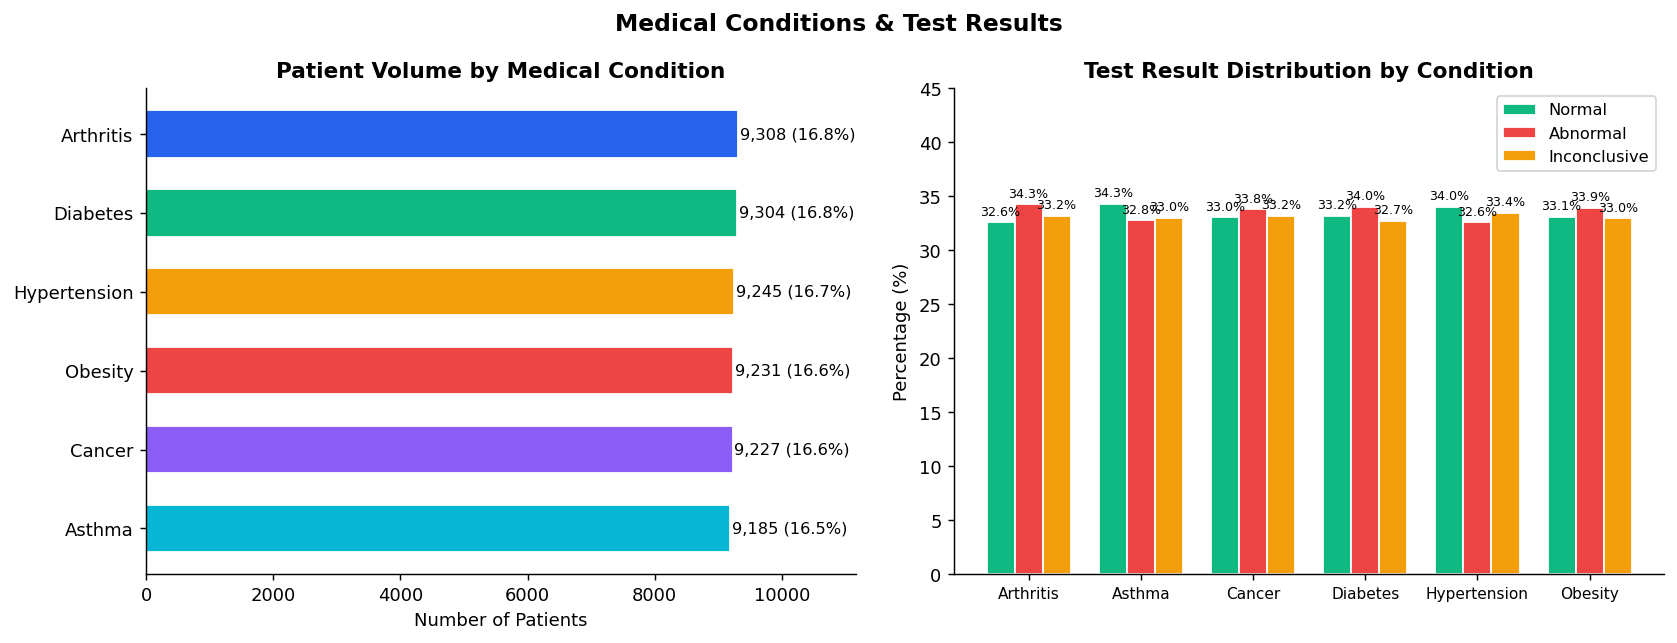

Abnormal test rate by condition:
                   Abnormal Rate (%)
Medical Condition                   
Arthritis                       34.3
Diabetes                        34.0
Obesity                         33.9
Cancer                          33.8
Asthma                          32.8
Hypertension                    32.6


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Condition counts
cond = df['Medical Condition'].value_counts().sort_values(ascending=True)
axes[0].barh(cond.index, cond.values, color=COLORS6[::-1], edgecolor='white', height=0.6)
for bar, val in zip(axes[0].patches, cond.values):
    axes[0].text(val+30, bar.get_y()+bar.get_height()/2,
                 f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
axes[0].set_xlabel('Number of Patients')
axes[0].set_title('Patient Volume by Medical Condition', fontweight='bold')
axes[0].set_xlim(0, cond.max()*1.2)

# Test results grouped bar
pivot_pct = (
    df.groupby(['Medical Condition','Test Results']).size()
      .unstack(fill_value=0)
      .div(df.groupby('Medical Condition').size(), axis=0) * 100
)
pivot_pct = pivot_pct[['Normal','Abnormal','Inconclusive']]
x = np.arange(len(pivot_pct)); w = 0.25
for i,(col,color) in enumerate(zip(['Normal','Abnormal','Inconclusive'],
                                    ['#10B981','#EF4444','#F59E0B'])):
    bars = axes[1].bar(x+i*w, pivot_pct[col], w, label=col, color=color, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x()+bar.get_width()/2, h+0.4,
                     f'{h:.1f}%', ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x+w)
axes[1].set_xticklabels(pivot_pct.index, fontsize=8.5)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 45)
axes[1].set_title('Test Result Distribution by Condition', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Medical Conditions & Test Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Abnormal rate table
ab_rate = (
    df[df['Test Results']=='Abnormal'].groupby('Medical Condition').size()
    / df.groupby('Medical Condition').size() * 100
).sort_values(ascending=False).round(1)
print('Abnormal test rate by condition:')
print(ab_rate.to_frame('Abnormal Rate (%)'))

**Finding:** All 6 conditions sit at ~16.5–16.8% prevalence each. Overall abnormal rate is **33.6%** (18,627 patients). Arthritis highest at 34.3%; Hypertension lowest at 32.6% — a 1.7 pp spread confirming this is a system-wide issue, not condition-specific.

### 5.3 Admissions & Length of Stay

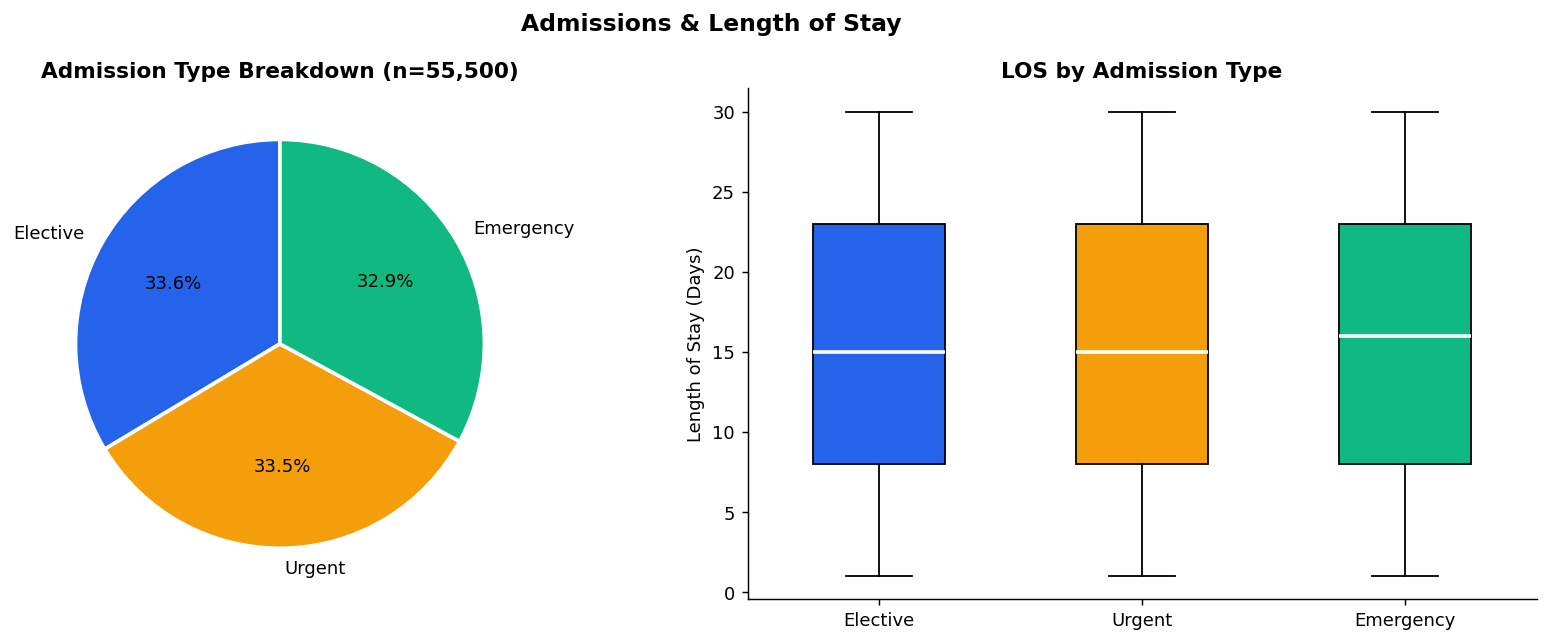

                Patients  Avg_Billing  Avg_LOS   Pct
Admission Type                                      
Elective           18618      25654.3     15.5  33.6
Emergency          18236      25544.2     15.6  32.9
Urgent             18538      25570.7     15.4  33.5


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Admission type pie
adm = df['Admission Type'].value_counts()
axes[0].pie(adm.values, labels=adm.index, colors=COLORS3,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title(f'Admission Type Breakdown (n={len(df):,})', fontweight='bold')

# LOS by admission type (boxplot)
data = [df[df['Admission Type']==t]['LOS'].values for t in ['Elective','Urgent','Emergency']]
bp = axes[1].boxplot(data, tick_labels=['Elective','Urgent','Emergency'],
                     patch_artist=True, widths=0.5,
                     medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], COLORS3):
    patch.set_facecolor(color)
axes[1].set_ylabel('Length of Stay (Days)')
axes[1].set_title('LOS by Admission Type', fontweight='bold')

plt.suptitle('Admissions & Length of Stay', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
adm_summary = df_clean.groupby('Admission Type').agg(
    Patients     = ('Billing Amount', 'count'),
    Avg_Billing  = ('Billing Amount', 'mean'),
    Avg_LOS      = ('LOS', 'mean')
).round(1)
adm_summary['Pct'] = (adm_summary['Patients'] / adm_summary['Patients'].sum() * 100).round(1)
print(adm_summary)

**Finding:** Elective (33.6%), Urgent (33.5%), Emergency (32.9%) — near-equal split. Average LOS is **15.5 days** with minimal variation across types. Discharge protocol drives LOS, not clinical complexity.

### 5.4 Financial Analysis

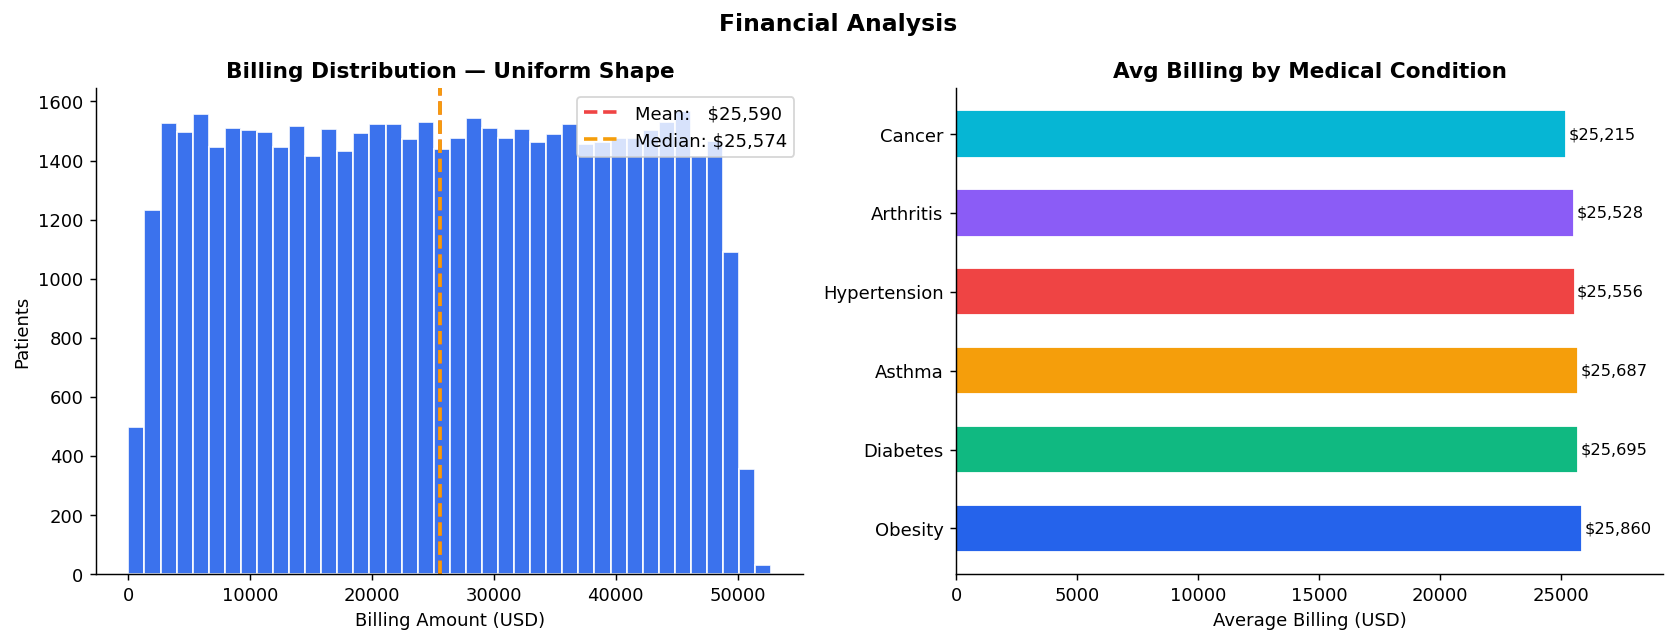

Total billing  : $1.42B
Avg per patient: $25,590
Median billing : $25,574
Skewness       : 0.0004  (≈0 confirms uniform distribution)

Avg billing by condition:
Medical Condition
Obesity         25860.0
Diabetes        25695.0
Asthma          25687.0
Hypertension    25556.0
Arthritis       25528.0
Cancer          25215.0
Name: Billing Amount, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Billing histogram
axes[0].hist(df_clean['Billing Amount'], bins=40, color='#2563EB', edgecolor='white', alpha=0.9)
axes[0].axvline(df_clean['Billing Amount'].mean(),   color='#EF4444', lw=2, ls='--',
                label=f'Mean:   ${df_clean["Billing Amount"].mean():,.0f}')
axes[0].axvline(df_clean['Billing Amount'].median(), color='#F59E0B', lw=2, ls='--',
                label=f'Median: ${df_clean["Billing Amount"].median():,.0f}')
axes[0].set_xlabel('Billing Amount (USD)')
axes[0].set_ylabel('Patients')
axes[0].set_title('Billing Distribution — Uniform Shape', fontweight='bold')
axes[0].legend()

# Billing by condition
bc = df_clean.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)
bars = axes[1].barh(bc.index, bc.values, color=COLORS6, edgecolor='white', height=0.6)
for bar, val in zip(bars, bc.values):
    axes[1].text(val+100, bar.get_y()+bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)
axes[1].set_xlabel('Average Billing (USD)')
axes[1].set_title('Avg Billing by Medical Condition', fontweight='bold')
axes[1].set_xlim(0, bc.max()*1.13)

plt.suptitle('Financial Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total billing  : ${df_clean["Billing Amount"].sum()/1e9:.2f}B')
print(f'Avg per patient: ${df_clean["Billing Amount"].mean():,.0f}')
print(f'Median billing : ${df_clean["Billing Amount"].median():,.0f}')
from scipy.stats import skew
print(f'Skewness       : {skew(df_clean["Billing Amount"]):.4f}  (≈0 confirms uniform distribution)')
print()
print('Avg billing by condition:')
print(bc.round(0))

**Finding:** Mean ($25,590) ≈ Median ($25,574), skewness ≈ 0 — billing is uniformly distributed. Obesity highest at $25,860; Cancer lowest at $25,215 — a $645 spread.

### 5.5 Insurance Coverage

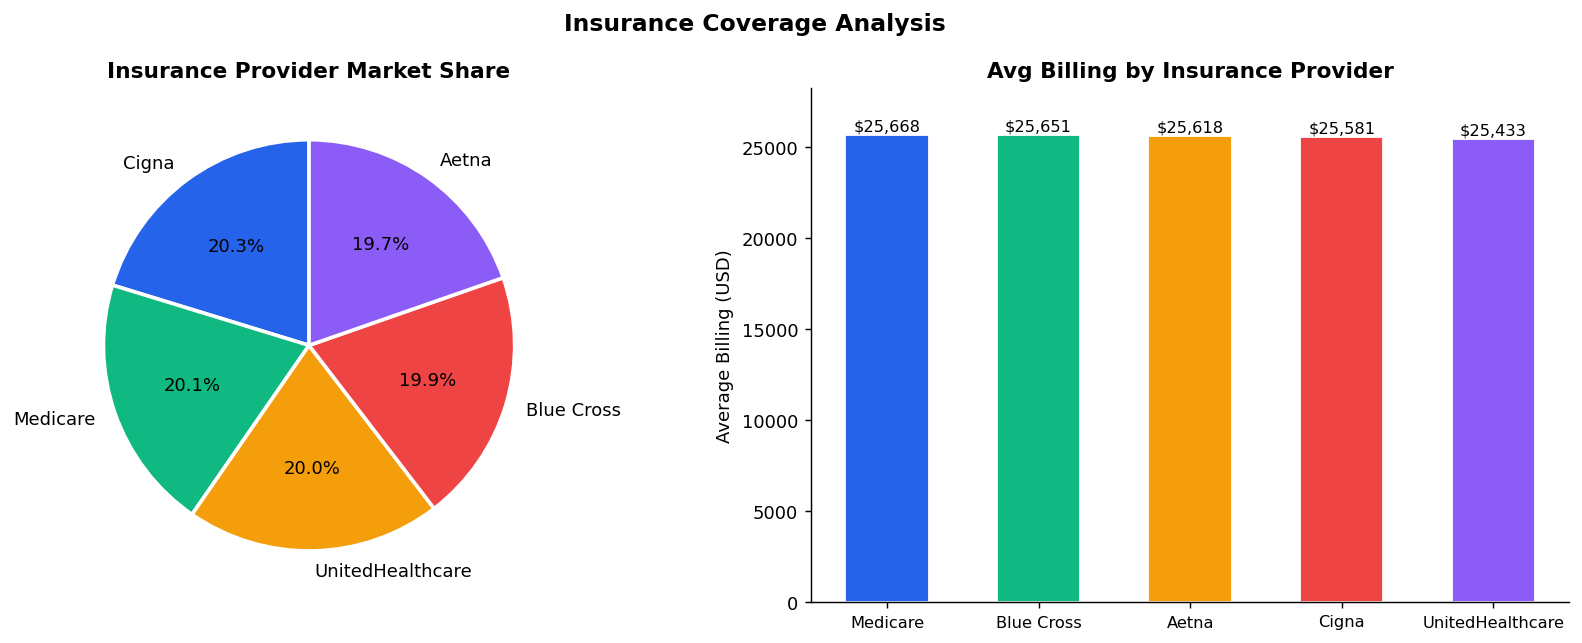

Insurance billing summary:
                    Patients  Avg_Billing  Share_%
Insurance Provider                                
Medicare               11132      25668.0     20.1
Blue Cross             11043      25651.0     19.9
Aetna                  10886      25618.0     19.7
Cigna                  11225      25581.0     20.3
UnitedHealthcare       11106      25433.0     20.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Insurance market share pie
ins_cnt = df['Insurance Provider'].value_counts()
axes[0].pie(ins_cnt.values, labels=ins_cnt.index, colors=COLORS6[:5],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Insurance Provider Market Share', fontweight='bold')

# Avg billing by insurance
ib = df_clean.groupby('Insurance Provider')['Billing Amount'].mean().sort_values(ascending=False)
bars = axes[1].bar(ib.index, ib.values, color=COLORS6[:5], edgecolor='white', width=0.55)
for bar, val in zip(bars, ib.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+50,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Average Billing (USD)')
axes[1].set_title('Avg Billing by Insurance Provider', fontweight='bold')
axes[1].set_ylim(0, ib.max()*1.1)
axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle('Insurance Coverage Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insurance billing summary:')
ins_summary = df_clean.groupby('Insurance Provider').agg(
    Patients=('Billing Amount','count'),
    Avg_Billing=('Billing Amount','mean')
).round(0)
ins_summary['Share_%'] = (ins_summary['Patients']/ins_summary['Patients'].sum()*100).round(1)
print(ins_summary.sort_values('Avg_Billing', ascending=False))

**Finding:** Medicare ($25,668) highest; UnitedHealthcare ($25,433) lowest — a $235 gap. Market share is near-uniform across all five providers (~20% each). Insurance type does not meaningfully drive billing.

### 5.6 Time-Based Trends

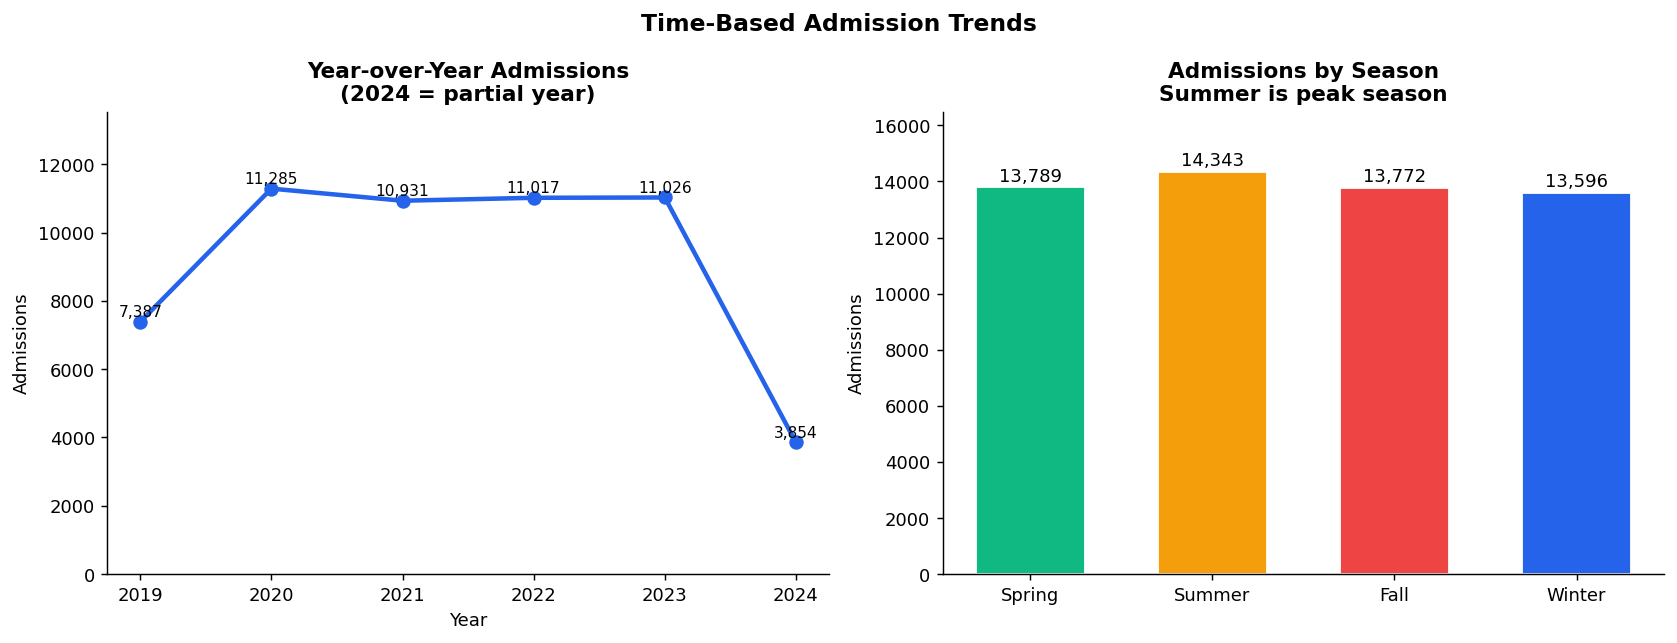

Admissions by season:
Season
Summer    14343
Spring    13789
Fall      13772
Winter    13596
Name: count, dtype: int64

Admissions by year:
Admission Year
2019     7387
2020    11285
2021    10931
2022    11017
2023    11026
2024     3854
dtype: int64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Year-over-year admissions
yr = df.groupby('Admission Year').size().reset_index(name='count')
axes[0].plot(yr['Admission Year'], yr['count'], color='#2563EB', lw=2.5, marker='o', ms=7)
for _, row in yr.iterrows():
    axes[0].text(row['Admission Year'], row['count']+150,
                 f'{row["count"]:,}', ha='center', fontsize=8.5)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Admissions')
axes[0].set_title('Year-over-Year Admissions\n(2024 = partial year)', fontweight='bold')
axes[0].set_ylim(0, yr['count'].max()*1.2)

# Seasonal bar
seas_order  = ['Spring','Summer','Fall','Winter']
seas_counts = df['Season'].value_counts().reindex(seas_order)
bars = axes[1].bar(seas_order, seas_counts.values,
                   color=['#10B981','#F59E0B','#EF4444','#2563EB'],
                   edgecolor='white', width=0.6)
for bar, val in zip(bars, seas_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+80,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Admissions')
axes[1].set_title('Admissions by Season\nSummer is peak season', fontweight='bold')
axes[1].set_ylim(0, seas_counts.max()*1.15)

plt.suptitle('Time-Based Admission Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Admissions by season:')
print(df['Season'].value_counts())
print()
print('Admissions by year:')
print(df.groupby('Admission Year').size())

**Finding:** Summer is peak admission season (14,343 admissions). Year-over-year volumes across 2019–2023 are stable. 2024 shows 3,854 — partial-year data only.

## 6. Outlier Detection — IQR + Z-Score

=== Billing Amount Outlier Detection ===
Q1 = $13,297   Q3 = $37,849   IQR = $24,552
Lower fence : $-23,530
Upper fence : $74,677
Actual range: $9 – $52,764
IQR outliers  : 0
Z-score outliers (|z|>3): 0

=== LOS Outlier Detection ===
LOS IQR outliers: 0


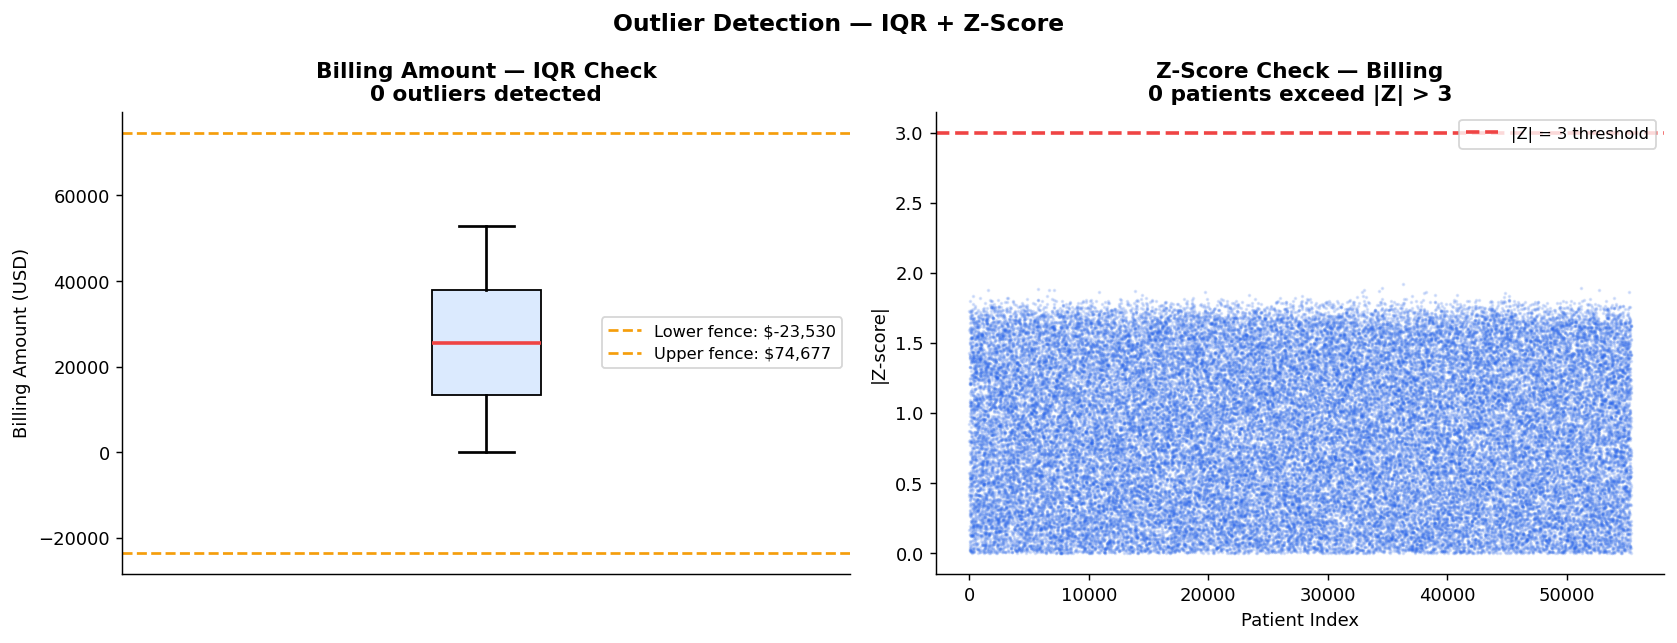

In [12]:
# ── IQR fences — Billing Amount ──────────────────────────────────────
Q1    = df_clean['Billing Amount'].quantile(0.25)
Q3    = df_clean['Billing Amount'].quantile(0.75)
IQR   = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df_clean[
    (df_clean['Billing Amount'] < lower) |
    (df_clean['Billing Amount'] > upper)
]

# ── Z-Score cross-check ───────────────────────────────────────────────
z_scores   = np.abs(stats.zscore(df_clean['Billing Amount']))
outliers_z = df_clean[z_scores > 3]

# ── LOS outliers ──────────────────────────────────────────────────────
Q1_l = df['LOS'].quantile(0.25)
Q3_l = df['LOS'].quantile(0.75)
IQR_l = Q3_l - Q1_l
outliers_los = df[
    (df['LOS'] < Q1_l - 1.5*IQR_l) |
    (df['LOS'] > Q3_l + 1.5*IQR_l)
]

print('=== Billing Amount Outlier Detection ===')
print(f'Q1 = ${Q1:,.0f}   Q3 = ${Q3:,.0f}   IQR = ${IQR:,.0f}')
print(f'Lower fence : ${lower:,.0f}')
print(f'Upper fence : ${upper:,.0f}')
print(f'Actual range: ${df_clean["Billing Amount"].min():,.0f} – ${df_clean["Billing Amount"].max():,.0f}')
print(f'IQR outliers  : {len(outliers_iqr)}')
print(f'Z-score outliers (|z|>3): {len(outliers_z)}')
print()
print('=== LOS Outlier Detection ===')
print(f'LOS IQR outliers: {len(outliers_los)}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bp = axes[0].boxplot(df_clean['Billing Amount'], vert=True, patch_artist=True,
                     boxprops={'facecolor':'#DBEAFE'},
                     medianprops={'color':'#EF4444','linewidth':2},
                     whiskerprops={'linewidth':1.5}, capprops={'linewidth':1.5})
axes[0].axhline(lower, color='#F59E0B', ls='--', lw=1.5, label=f'Lower fence: ${lower:,.0f}')
axes[0].axhline(upper, color='#F59E0B', ls='--', lw=1.5, label=f'Upper fence: ${upper:,.0f}')
axes[0].set_ylabel('Billing Amount (USD)')
axes[0].set_title(f'Billing Amount — IQR Check\n0 outliers detected', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xticks([])

axes[1].scatter(range(len(df_clean)), z_scores, alpha=0.15, s=1, color='#2563EB')
axes[1].axhline(3, color='#EF4444', lw=2, ls='--', label='|Z| = 3 threshold')
axes[1].set_xlabel('Patient Index')
axes[1].set_ylabel('|Z-score|')
axes[1].set_title(f'Z-Score Check — Billing\n0 patients exceed |Z| > 3', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Outlier Detection — IQR + Z-Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** 0 outliers detected by either method. IQR fences ($-23,530 to $74,677) sit well outside the actual data range ($9–$52,764). Billing is uniformly distributed — no extreme-cost patients in this dataset.

## 7. Statistical Testing

### 7.1 T-Test — Gender vs Billing
_H₀: Male and Female billing amounts are equal. Reject H₀ if p < 0.05._

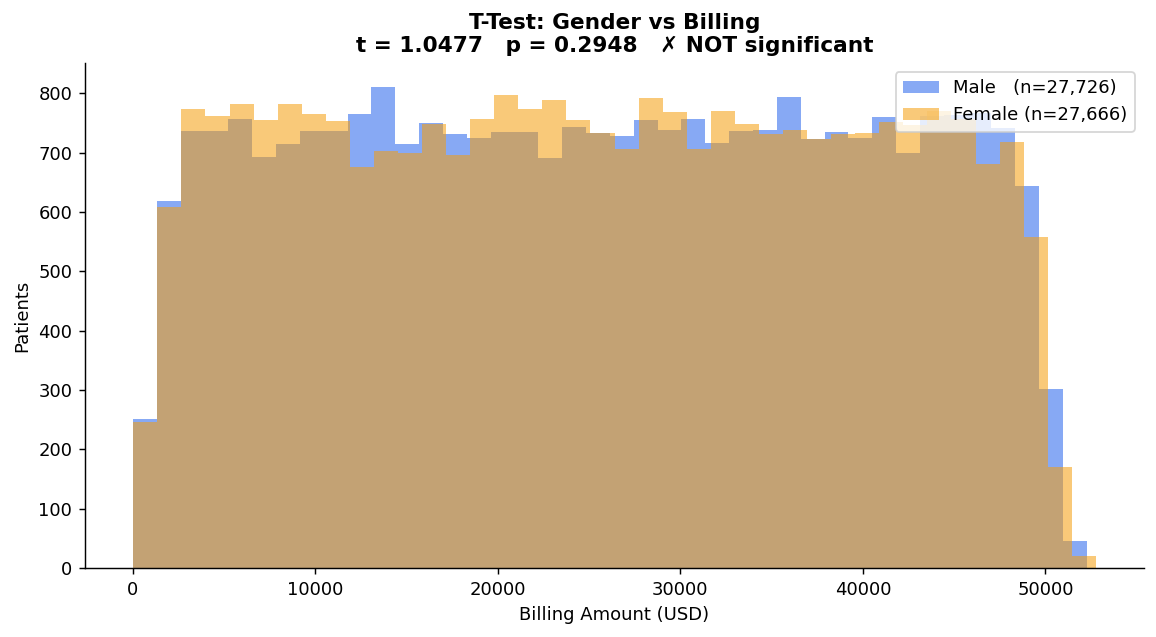

Male mean billing  : $25,653
Female mean billing: $25,527
Difference         : $126
T-statistic        : 1.0477
P-value            : 0.2948
Decision           : FAIL TO REJECT H0
Conclusion         : Gender does NOT significantly affect billing.


In [13]:
male_billing   = df_clean[df_clean['Gender'] == 'Male']['Billing Amount']
female_billing = df_clean[df_clean['Gender'] == 'Female']['Billing Amount']

t_stat, p_ttest = stats.ttest_ind(male_billing, female_billing)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(male_billing,   bins=40, alpha=0.55, color='#2563EB', label=f'Male   (n={len(male_billing):,})')
ax.hist(female_billing, bins=40, alpha=0.55, color='#F59E0B', label=f'Female (n={len(female_billing):,})')
ax.set_xlabel('Billing Amount (USD)')
ax.set_ylabel('Patients')
ax.set_title(f'T-Test: Gender vs Billing\nt = {t_stat:.4f}   p = {p_ttest:.4f}   ✗ NOT significant',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Male mean billing  : ${male_billing.mean():,.0f}')
print(f'Female mean billing: ${female_billing.mean():,.0f}')
print(f'Difference         : ${abs(male_billing.mean()-female_billing.mean()):,.0f}')
print(f'T-statistic        : {t_stat:.4f}')
print(f'P-value            : {p_ttest:.4f}')
print(f'Decision           : {"REJECT H0" if p_ttest < 0.05 else "FAIL TO REJECT H0"}')
print(f'Conclusion         : Gender does NOT significantly affect billing.')

### 7.2 One-Way ANOVA — Medical Condition vs Billing
_H₀: All 6 conditions have the same mean billing. Reject H₀ if p < 0.05._

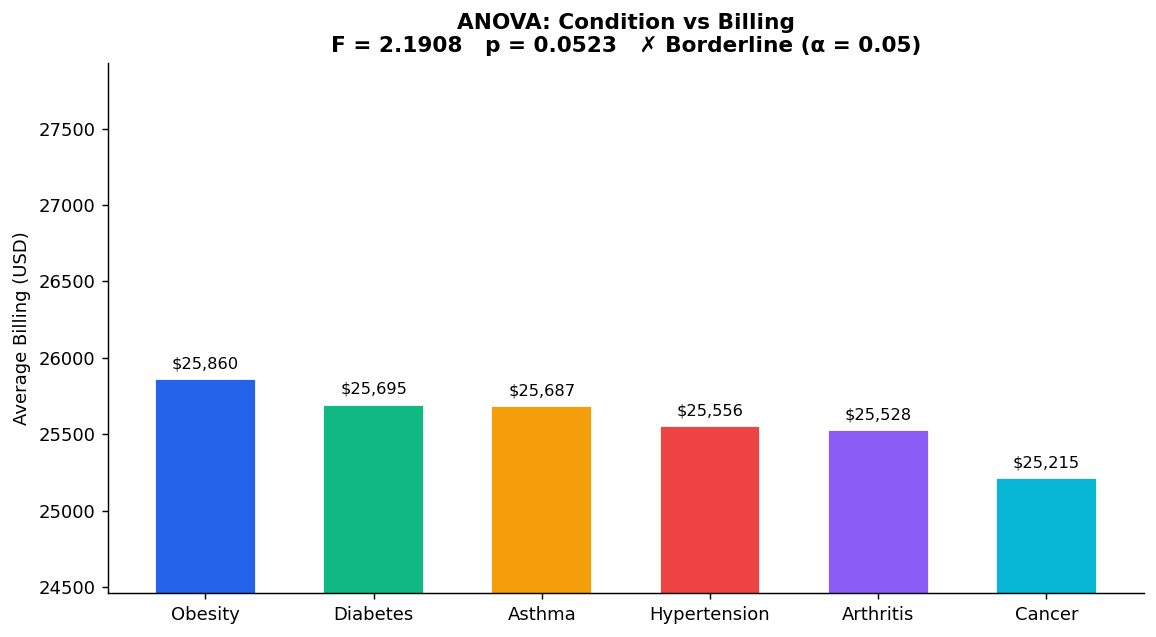

Highest avg billing: Obesity — $25,860
Lowest avg billing : Cancer  — $25,215
F-statistic        : 2.1908
P-value            : 0.0523
Decision           : FAIL TO REJECT H0
Conclusion         : Condition billing differences are borderline — just above α=0.05.


In [14]:
condition_groups = [
    df_clean[df_clean['Medical Condition'] == c]['Billing Amount']
    for c in df_clean['Medical Condition'].unique()
]
f_stat, p_anova = stats.f_oneway(*condition_groups)

bc = df_clean.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(bc.index, bc.values, color=COLORS6, edgecolor='white', width=0.6)
for bar, val in zip(bars, bc.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+50,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Average Billing (USD)')
ax.set_ylim(bc.min()*0.97, bc.max()*1.08)
ax.set_title(f'ANOVA: Condition vs Billing\nF = {f_stat:.4f}   p = {p_anova:.4f}   ✗ Borderline (α = 0.05)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Highest avg billing: Obesity — ${bc["Obesity"]:,.0f}')
print(f'Lowest avg billing : Cancer  — ${bc["Cancer"]:,.0f}')
print(f'F-statistic        : {f_stat:.4f}')
print(f'P-value            : {p_anova:.4f}')
print(f'Decision           : {"REJECT H0" if p_anova < 0.05 else "FAIL TO REJECT H0"}')
print(f'Conclusion         : Condition billing differences are borderline — just above α=0.05.')

### 7.3 Chi-Square — Medical Condition vs Admission Type
_H₀: Admission type and medical condition are independent. Reject H₀ if p < 0.05._

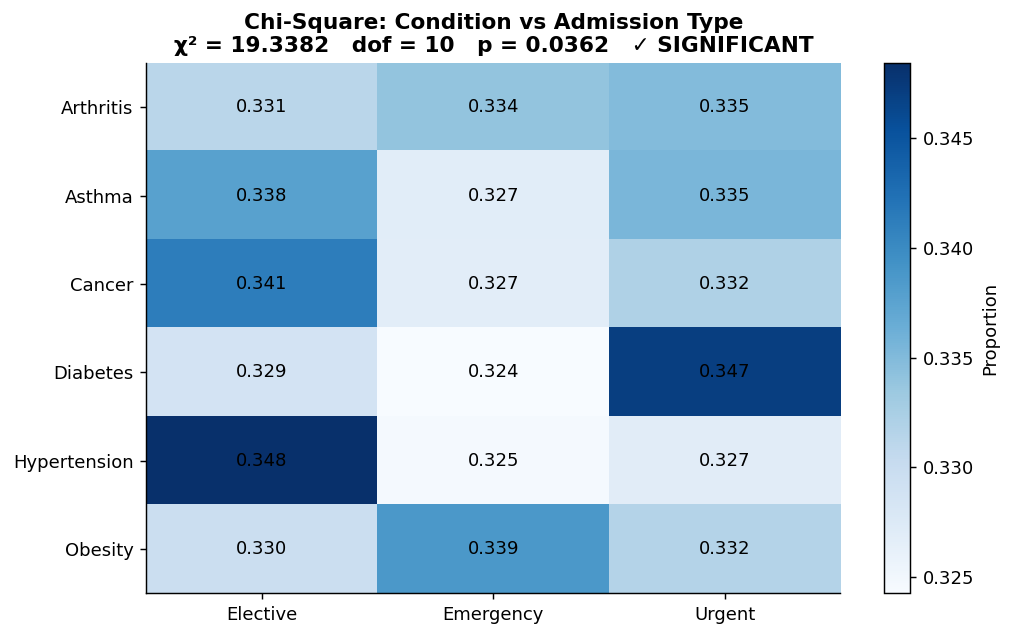

Chi-square statistic: 19.3382
Degrees of freedom  : 10
P-value             : 0.0362
Decision            : REJECT H0
Conclusion          : Admission type and condition are NOT independent (p < 0.05).
                      This is the standout result — condition carries weak but real
                      information about how patients are admitted.


In [15]:
contingency = pd.crosstab(df['Medical Condition'], df['Admission Type'])
chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(contingency)

# Heatmap of proportions
ct_pct = contingency.div(contingency.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(ct_pct.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(3))
ax.set_xticklabels(contingency.columns)
ax.set_yticks(range(6))
ax.set_yticklabels(contingency.index)
for i in range(6):
    for j in range(3):
        ax.text(j, i, f'{ct_pct.values[i,j]:.3f}',
                ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label='Proportion')
ax.set_title(f'Chi-Square: Condition vs Admission Type\n'
             f'χ² = {chi2_stat:.4f}   dof = {dof}   p = {p_chi2:.4f}   ✓ SIGNIFICANT',
             fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Chi-square statistic: {chi2_stat:.4f}')
print(f'Degrees of freedom  : {dof}')
print(f'P-value             : {p_chi2:.4f}')
print(f'Decision            : {"REJECT H0" if p_chi2 < 0.05 else "FAIL TO REJECT H0"}')
print(f'Conclusion          : Admission type and condition are NOT independent (p < 0.05).')
print(f'                      This is the standout result — condition carries weak but real')
print(f'                      information about how patients are admitted.')

**Statistical Testing Summary:**

| Test | Variables | Result | p-Value | Conclusion |
|---|---|---|---|---|
| Independent T-test | Gender vs Billing | FAIL TO REJECT H₀ | p = 0.295 | Gender does NOT drive billing |
| One-Way ANOVA | Condition vs Billing | FAIL TO REJECT H₀ | p = 0.052 | Borderline — condition effect near but below significance |
| Chi-Square | Condition vs Admission Type | **REJECT H₀** | p = 0.036 | Condition and admission type ARE related |

## 8. Regression Analysis
_Objective: Which clinical features best predict billing? How much billing variation can they explain?_

In [16]:
# Feature encoding
le = LabelEncoder()
reg_df = df_clean.copy()
reg_df['Gender_enc']    = le.fit_transform(reg_df['Gender'])
reg_df['Condition_enc'] = le.fit_transform(reg_df['Medical Condition'])
reg_df['Admission_enc'] = le.fit_transform(reg_df['Admission Type'])

X = reg_df[['Age', 'LOS', 'Gender_enc', 'Condition_enc', 'Admission_enc']]
y = reg_df['Billing Amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'R² Score         : {r2:.4f}')
print(f'Mean Abs Error   : ${mae:,.0f}  ({mae/y.mean()*100:.0f}% of avg billing)')
print()

feat_names = ['Age', 'Days Hospitalized', 'Gender', 'Medical Condition', 'Admission Type']
print('Feature Coefficients:')
for name, coef in zip(feat_names, model.coef_):
    print(f'  {name:<22}: ${coef:+.2f}')

Training samples : 44,313
Test samples     : 11,079
R² Score         : 0.0002
Mean Abs Error   : $12,361  (48% of avg billing)

Feature Coefficients:
  Age                   : $-1.30
  Days Hospitalized     : $-6.53
  Gender                : $+46.34
  Medical Condition     : $+52.26
  Admission Type        : $-52.60


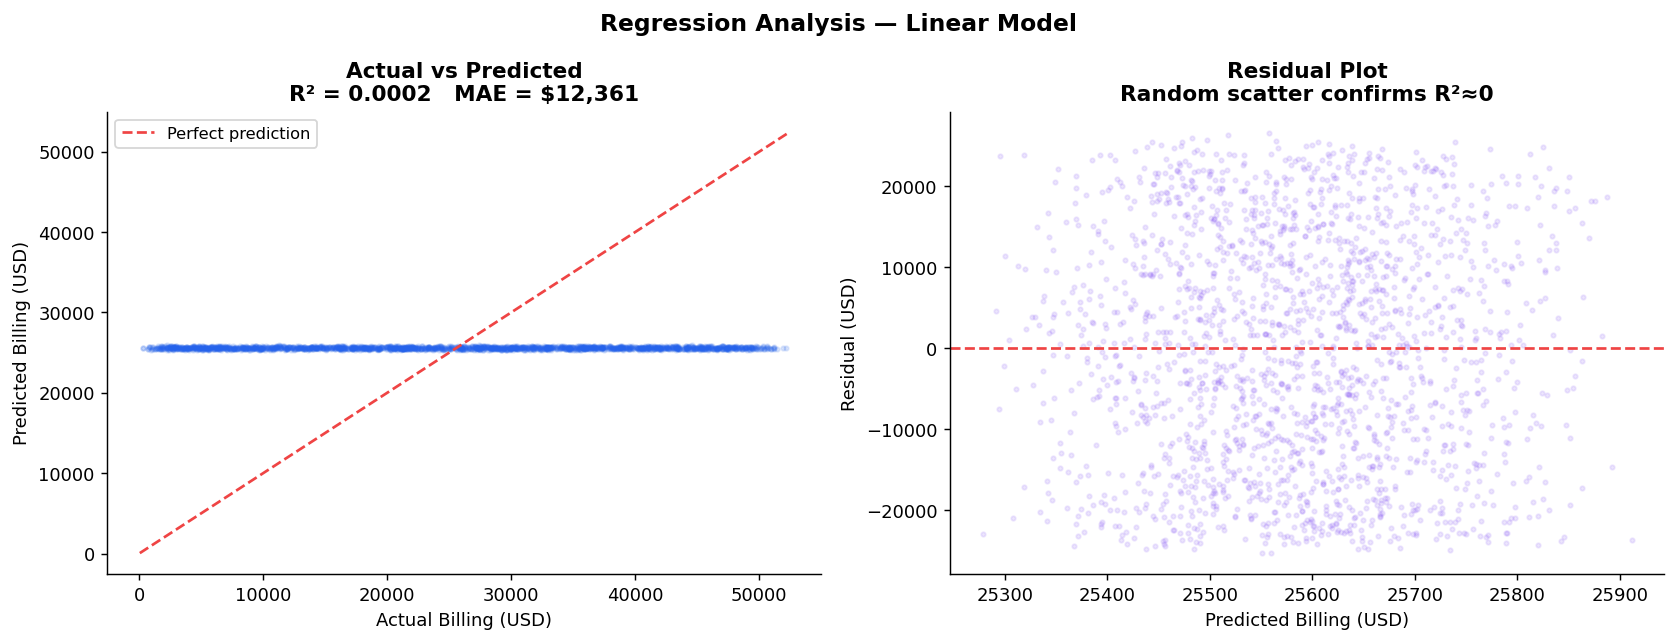

In [17]:
import random
random.seed(42)
sample_idx = random.sample(range(len(y_test)), min(2000, len(y_test)))
y_test_arr = np.array(y_test)
residuals  = y_test_arr - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test_arr[sample_idx], y_pred[sample_idx],
                alpha=0.15, s=6, color='#2563EB')
lims = [min(y_test_arr.min(), y_pred.min()), max(y_test_arr.max(), y_pred.max())]
axes[0].plot(lims, lims, color='#EF4444', lw=1.5, ls='--', label='Perfect prediction')
axes[0].set_xlabel('Actual Billing (USD)')
axes[0].set_ylabel('Predicted Billing (USD)')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}   MAE = ${mae:,.0f}', fontweight='bold')
axes[0].legend(fontsize=9)

# Residuals
axes[1].scatter(y_pred[sample_idx], residuals[sample_idx],
                alpha=0.15, s=6, color='#8B5CF6')
axes[1].axhline(0, color='#EF4444', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted Billing (USD)')
axes[1].set_ylabel('Residual (USD)')
axes[1].set_title('Residual Plot\nRandom scatter confirms R²≈0', fontweight='bold')

plt.suptitle('Regression Analysis — Linear Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** R²≈0. The model explains essentially none of the billing variation. MAE=$12,361 on $25,590 average billing = 48% error rate — no better than always predicting the mean. All coefficients are negligible relative to the $52,764 billing range. The variables that actually drive billing (procedures, room type, lab tests) are not in this dataset.

## 9. SQL Equivalents (MySQL 8.0)

The pandas operations above map directly to these MySQL queries:

In [18]:
sql_queries = {
    'Avg billing + LOS by condition': """
SELECT
    Medical_Condition,
    COUNT(*)                                                       AS patient_count,
    ROUND(AVG(Billing_Amount), 2)                                  AS avg_billing,
    ROUND(AVG(DATEDIFF(Discharge_Date, Date_of_Admission)), 1)     AS avg_los_days
FROM healthcare_records
WHERE Billing_Amount > 0
GROUP BY Medical_Condition
ORDER BY avg_billing DESC;
""",
    'Abnormal test rate by condition': """
SELECT
    Medical_Condition,
    COUNT(*)                                                           AS total,
    SUM(CASE WHEN Test_Results = 'Abnormal' THEN 1 ELSE 0 END)        AS abnormal_count,
    ROUND(
        SUM(CASE WHEN Test_Results = 'Abnormal' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*), 1
    )                                                                  AS abnormal_pct
FROM healthcare_records
GROUP BY Medical_Condition
ORDER BY abnormal_pct DESC;
""",
    'Admission type summary with LOS': """
SELECT
    Admission_Type,
    COUNT(*)                                                           AS patient_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1)                AS pct_of_total,
    ROUND(AVG(DATEDIFF(Discharge_Date, Date_of_Admission)), 1)        AS avg_los_days,
    ROUND(AVG(Billing_Amount), 2)                                      AS avg_billing
FROM healthcare_records
WHERE Billing_Amount > 0
GROUP BY Admission_Type
ORDER BY patient_count DESC;
""",
    'Negative billing data quality flag': """
SELECT
    COUNT(*)                      AS negative_count,
    ROUND(MIN(Billing_Amount), 2) AS min_amount,
    ROUND(AVG(Billing_Amount), 2) AS avg_negative
FROM healthcare_records
WHERE Billing_Amount < 0;
"""
}

for title, query in sql_queries.items():
    print(f'── {title} ──')
    print(query)

── Avg billing + LOS by condition ──

SELECT
    Medical_Condition,
    COUNT(*)                                                       AS patient_count,
    ROUND(AVG(Billing_Amount), 2)                                  AS avg_billing,
    ROUND(AVG(DATEDIFF(Discharge_Date, Date_of_Admission)), 1)     AS avg_los_days
FROM healthcare_records
WHERE Billing_Amount > 0
GROUP BY Medical_Condition
ORDER BY avg_billing DESC;

── Abnormal test rate by condition ──

SELECT
    Medical_Condition,
    COUNT(*)                                                           AS total,
    SUM(CASE WHEN Test_Results = 'Abnormal' THEN 1 ELSE 0 END)        AS abnormal_count,
    ROUND(
        SUM(CASE WHEN Test_Results = 'Abnormal' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*), 1
    )                                                                  AS abnormal_pct
FROM healthcare_records
GROUP BY Medical_Condition
ORDER BY abnormal_pct DESC;

── Admission type summary with LOS ──

SELECT
    Admission_Typ

## 10. Key Findings Summary

In [19]:
bc2  = df_clean.groupby('Medical Condition')['Billing Amount'].mean()
ib2  = df_clean.groupby('Insurance Provider')['Billing Amount'].mean()
ab2  = (df[df['Test Results']=='Abnormal'].groupby('Medical Condition').size()
        / df.groupby('Medical Condition').size() * 100)
los2 = df.groupby('Admission Type')['LOS'].mean()

print('─── Key Findings ──────────────────────────────────────────────────────')
print(f'Dataset   : {len(df):,} patients  |  ${df_clean["Billing Amount"].sum()/1e9:.2f}B total billing')
print()
print(f'1. Obesity highest billing  : ${bc2["Obesity"]:,.0f}  |  Cancer lowest: ${bc2["Cancer"]:,.0f}  |  Spread: ${bc2["Obesity"]-bc2["Cancer"]:,.0f}')
print(f'2. Abnormal test rate       : {(df["Test Results"]=="Abnormal").mean()*100:.1f}%  ({(df["Test Results"]=="Abnormal").sum():,} patients)')
print(f'   Arthritis (highest)      : {ab2["Arthritis"]:.1f}%  |  Hypertension (lowest): {ab2["Hypertension"]:.1f}%')
print(f'3. LOS range by adm. type   : {los2.min():.1f}–{los2.max():.1f} days  (effectively flat)')
print(f'4. Medicare avg billing     : ${ib2["Medicare"]:,.0f} (highest)  |  UnitedHealthcare: ${ib2["UnitedHealthcare"]:,.0f} (lowest)')
print(f'5. Outliers                 : 0 (IQR)  |  0 (Z-score)  |  fences: ${Q1-1.5*IQR:,.0f} to ${Q3+1.5*IQR:,.0f}')
print(f'6. T-test  (gender)         : t={t_stat:.4f}  p={p_ttest:.4f}  → NOT significant')
print(f'7. ANOVA   (condition)      : F={f_stat:.4f}  p={p_anova:.4f}  → Borderline, NOT significant at α=0.05')
print(f'8. Chi-sq  (cond vs adm)    : χ²={chi2_stat:.4f}  dof={dof}  p={p_chi2:.4f}  → SIGNIFICANT')
print(f'9. Regression R²            : {r2:.4f}  |  MAE=${mae:,.0f}  → billing not predictable from clinical features')
print(f'10. Peak season             : Summer ({df["Season"].value_counts()["Summer"]:,} admissions)')
print(f'11. Negative billing records: {(df["Billing Amount"]<0).sum()} (0.19% — data quality flag)')

─── Key Findings ──────────────────────────────────────────────────────
Dataset   : 55,500 patients  |  $1.42B total billing

1. Obesity highest billing  : $25,860  |  Cancer lowest: $25,215  |  Spread: $645
2. Abnormal test rate       : 33.6%  (18,627 patients)
   Arthritis (highest)      : 34.3%  |  Hypertension (lowest): 32.6%
3. LOS range by adm. type   : 15.4–15.6 days  (effectively flat)
4. Medicare avg billing     : $25,668 (highest)  |  UnitedHealthcare: $25,433 (lowest)
5. Outliers                 : 0 (IQR)  |  0 (Z-score)  |  fences: $-23,530 to $74,677
6. T-test  (gender)         : t=1.0477  p=0.2948  → NOT significant
7. ANOVA   (condition)      : F=2.1908  p=0.0523  → Borderline, NOT significant at α=0.05
8. Chi-sq  (cond vs adm)    : χ²=19.3382  dof=10  p=0.0362  → SIGNIFICANT
9. Regression R²            : 0.0002  |  MAE=$12,361  → billing not predictable from clinical features
10. Peak season             : Summer (14,343 admissions)
11. Negative billing records: 108 (0.1